In [85]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
import os
from sklearn.metrics import r2_score, mean_squared_error
import sys
import shap
# from lifelines import KaplanMeierFitter
# from lifelines.statistics import logrank_test

In [7]:
pkg_path = str(Path(os.path.abspath('')).parent.absolute())
sys.path.insert(0, pkg_path)
# print(pkg_path)
data_path=pkg_path+'/results/'
FNN_file_name='model_results_summary_for_Linear_Model.csv'

FNN_model_stats=pd.read_csv(data_path+FNN_file_name)
FNN_model_stats.sort_values(by='best_r2', ascending=False, inplace=True)
FNN_model_stats.head()


,file_name,mse_avg,mse_std,r2_avg,r2_std,mse,r2,best_model_filename,best_r2
42,Radiomic_Features_CaPTk_segm_DSC_ap-rCBV_ED.csv,113832.973437,26674.540265,-0.337353,0.757463,"[101211.0625, 101381.9765625, 149219.328125, 7...","[0.53214430809021, -1.6663684844970703, -0.308...",best_linear_model_for_Radiomic_Features_CaPTk_...,0.532144
21,Radiomic_Features_CaPTk_segm_DTI_AD_NC.csv,150960.212500,74801.254338,-0.623397,0.776163,"[87997.671875, 138334.90625, 296821.59375, 123...","[-0.28283143043518066, -2.05607271194458, -0.5...",best_linear_model_for_Radiomic_Features_CaPTk_...,0.285185
14,Radiomic_Features_CaPTk_automaticsegm_DSC_ap-r...,149921.679688,30233.591665,0.039820,0.120156,"[154401.390625, 123462.6484375, 172005.6875, 1...","[-0.12214720249176025, 0.22789400815963745, -0...",best_linear_model_for_Radiomic_Features_CaPTk_...,0.227894
29,Radiomic_Features_CaPTk_segm_DTI_FA_ED.csv,152228.147656,73566.890357,-0.233849,0.356527,"[51533.95703125, 134610.609375, 195068.3125, 1...","[-0.7542406320571899, -0.13952744007110596, 0....",best_linear_model_for_Radiomic_Features_CaPTk_...,0.203358
38,Radiomic_Features_CaPTk_segm_DTI_RD_ED.csv,138706.848438,52276.030156,-0.191680,0.409855,"[58387.203125, 129199.8359375, 203639.625, 115...","[-0.9875284433364868, -0.09372329711914062, 0....",best_linear_model_for_Radiomic_Features_CaPTk_...,0.186497


In [8]:
print('The highest performing simple NN models are:')
for model in FNN_model_stats['file_name'].iloc[0:10].tolist():
    print(model)

The highest performing simple NN models are:
Radiomic_Features_CaPTk_segm_DSC_ap-rCBV_ED.csv
Radiomic_Features_CaPTk_segm_DTI_AD_NC.csv
Radiomic_Features_CaPTk_automaticsegm_DSC_ap-rCBV_ED.csv
Radiomic_Features_CaPTk_segm_DTI_FA_ED.csv
Radiomic_Features_CaPTk_segm_DTI_RD_ED.csv
Radiomic_Features_CaPTk_segm_DTI_RD_NC.csv
Radiomic_Features_CaPTk_segm_FLAIR_NC.csv
Radiomic_Features_CaPTk_segm_DTI_AD_ED.csv
Radiomic_Features_CaPTk_automaticsegm_T2_ED.csv
Radiomic_Features_CaPTk_segm_T2_NC.csv


In [9]:
file_type_mapping = {
    'DTI': 1,
    'DSC': 2,
    'T2': 3,
    'Flair': 4,
    'T1': 5,
    'T1GD': 6
}

# Define colors for 'NC', 'ET', 'ED'
def get_color(file_name):
    if 'NC' in file_name:
        return 'red'
    elif 'ET' in file_name:
        return 'blue'
    elif 'ED' in file_name:
        return 'green'
    return 'black'  # Default color for other cases

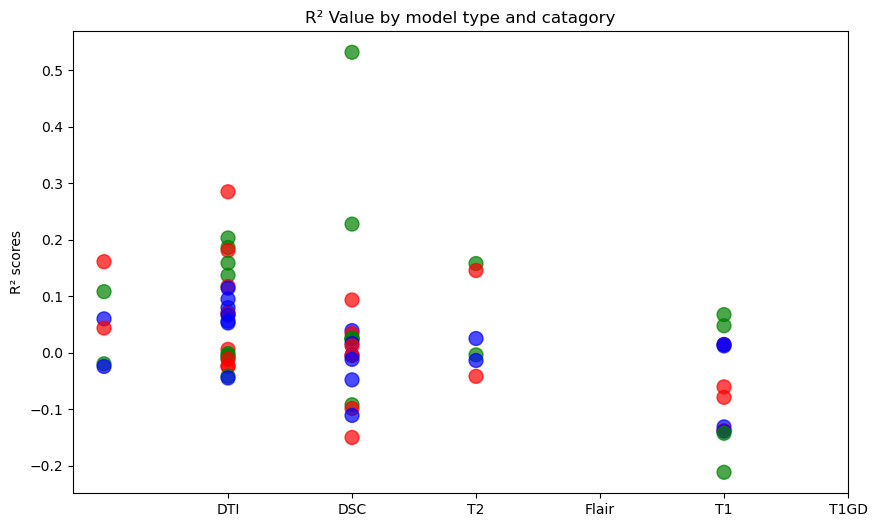

In [11]:

df=FNN_model_stats
# Map the 'file_name' to x-axis positions and colors
df['file_type'] = df['file_name'].apply(lambda x: next((key for key in file_type_mapping if key in x), 'Unknown'))
df['x_position'] = df['file_type'].apply(lambda x: file_type_mapping.get(x, 0))
df['color'] = df['file_name'].apply(get_color)

# Create the plot
plt.figure(figsize=(10, 6))

# Plot the data
plt.scatter(df['x_position'], df['best_r2'], c=df['color'], s=100, alpha=0.7)

# Set x-ticks with appropriate labels
plt.xticks(list(file_type_mapping.values()), list(file_type_mapping.keys()))

# Set labels and title
plt.ylabel('R² scores')
plt.title('R² Value by model type and catagory')

# Show the plot
plt.grid(False)
plt.show()

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint,ReduceLROnPlateau
import tensorflow as tf
from tensorflow.keras import layers, models,regularizers


pkg_path = str(Path(os.path.abspath('')).parent.absolute())
sys.path.insert(0, pkg_path)
data_path=pkg_path+'/Datasets/UPENN_GBM/csvs/'

data_availability = pd.read_csv(os.path.join(data_path, 'UPENN-GBM_data_availability.csv'))
data_availability = data_availability[data_availability['Overall Survival'] != 'not available']
patient_ids = data_availability['ID']

clinical_info = pd.read_csv(os.path.join(data_path, 'UPENN-GBM_clinical_info_v2.1.csv'))
clinical_info = clinical_info[clinical_info['ID'].isin(patient_ids)]
clinical_info = clinical_info.set_index('ID')
survival_days = clinical_info['Survival_from_surgery_days_UPDATED']

lr_reduction = ReduceLROnPlateau(monitor='val_loss', patience=3, factor=0.5, min_lr=0.0001)
early_stopping = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)
model_checkpoint = ModelCheckpoint('best_model.h5', monitor='val_loss', save_best_only=True)

def drop_correlated_features(df, threshold=0.9):
    corr_matrix = df.corr().abs()
    upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
    to_drop = [column for column in upper.columns if any(upper[column] > threshold)]
    df = df.drop(columns=to_drop)
    return df

def train_transform(radiomeric_features, survival_days,seed=1):
    X = radiomeric_features
    Y = survival_days
    X, Y = X.align(Y, join='inner', axis=0)
    Y= Y.astype(int) 
    X_train, X_test, y_train, y_test = train_test_split(X, Y, test_size=0.2, random_state=seed)
    features= X_train.columns
    scaler = StandardScaler()
    X_train = scaler.fit_transform(X_train)
    X_test = scaler.transform(X_test)
    return X_train, X_test, y_train, y_test, features

def get_linear_model(X_train_shape, drop_rate = 0.3, regularizer=tf.keras.regularizers.l2(0.01)):
    model = models.Sequential()
    model.add(layers.InputLayer(input_shape=(X_train_shape[1],))) 
    model.add(layers.Dense(128, activation='relu', kernel_regularizer=regularizer))
    model.add(layers.Dropout(drop_rate))
    model.add(layers.Dense(64, activation='relu', kernel_regularizer=regularizer))
    model.add(layers.Dropout(drop_rate))
    model.add(layers.Dense(32, activation='relu', kernel_regularizer=regularizer))
    model.add(layers.Dense(1))  
    model.compile(optimizer='adam', loss='mean_squared_error', metrics=['mae'])
    return model

def train_linear_model(model, X_train, y_train, epochs=40, batch_size=32):
    history = model.fit(
    X_train, y_train,  
    epochs=epochs,                 
    batch_size=batch_size,             
    validation_split=0.2,      
    callbacks=[early_stopping, model_checkpoint, lr_reduction]  
    )
    return history

def run_experiment_for_file(file_path, random_seeds=[1, 2, 3, 4, 5]):
    df = pd.read_csv(file_path)
    df = df[df['SubjectID'].isin(patient_ids)]
    df = df.set_index('SubjectID')
    df = drop_correlated_features(df)
    df = df.dropna()
    results = {'mse': [], 'r2': []}

    for seed in random_seeds:
        # Split data and train model
        tf.random.set_seed(seed)
        X_train, X_test, y_train, y_test, features = train_transform(df, survival_days, seed)
        global model_label

        with tf.device('/CPU:0'):
            model = get_linear_model(X_train.shape)
            history = train_linear_model(model, X_train, y_train)
        model_label = 'Linear_Model'

        # Makes predictions
        y_pred = model.predict(X_test)
        
        # Calculates MSE and R2 score
        mse = mean_squared_error(y_test, y_pred)
        r2 = r2_score(y_test, y_pred)
        
        # Stores results
        results['mse'].append(mse)
        results['r2'].append(r2)
        print(f"For file {file_path} and Seed {seed}- MSE: {mse}, R2: {r2}")


    # Calculates average and std dev for MSE and R2
    mse_avg = np.mean(results['mse'])
    mse_std = np.std(results['mse'])
    r2_avg = np.mean(results['r2'])
    r2_std = np.std(results['r2'])

    # Save the best model to a file
   
    
    return {
        'file_name': file_path,
        'features': features,
        'mse_avg': mse_avg,
        'mse_std': mse_std,
        'r2_avg': r2_avg,
        'r2_std': r2_std,
        'mse': results['mse'],
        'r2': results['r2'],
        'model': model
    }


In [81]:
DSC_features_csv='/home/ee577/project/Datasets/UPENN_GBM/csvs/Radiomic_Features_CaPTk_automaticsegm_DSC_ap-rCBV_ED.csv'
df = pd.read_csv(DSC_features_csv)
df = df[df['SubjectID'].isin(patient_ids)]
df = df.set_index('SubjectID')
df = drop_correlated_features(df)
df = df.dropna()

X_train, X_test, y_train, y_test, features = train_transform(df, survival_days, 1)

In [ ]:


DSC_resutls= run_experiment_for_file(file_path=DSC_features_csv, random_seeds=[1])

In [67]:
import pickle

def save_results_with_model(results, file_name):
    # First, save the model
    model = results['model']
    model_file = file_name.replace('.pkl', '_model.h5')
    model.save(model_file)  # If it's a Keras model

    # Now save the rest of the results (without the model) using pickle
    results_to_save = {
        'file_name': results['file_name'],
        'mse_avg': results['mse_avg'],
        'mse_std': results['mse_std'],
        'r2_avg': results['r2_avg'],
        'r2_std': results['r2_std'],
        'mse': results['mse'],
        'r2': results['r2'],
        'model_file': model_file  # Store the model filename in the result
    }

    with open(file_name, 'wb') as f:
        pickle.dump(results_to_save, f)

save_results_with_model(DSC_resutls, 'simple_DSC_model.pkl')

In [ ]:
def load_pickle_model(pickle_file_path):
    with open(pickle_file_path, 'rb') as file:
        model = pickle.load(file)  # Assuming the model is pickled inside the file
    return model

# Example Usage:
pickle_model_path = 'simple_DSC_model.pkl'  # Replace with the path to your pickle file
DSC_model = load_pickle_model(pickle_model_path)

In [88]:
def compute_shap_values_keras(model, X_train):
    explainer = shap.KernelExplainer(model.predict, X_train)
    shap_values = explainer.shap_values(X_train)
    return shap_values


def sum_absolute_shap_values(shap_values, feature_names):
    summed_shap_values = np.sum(np.abs(shap_values), axis=0)
    
    shap_df = pd.DataFrame({
        'Feature': feature_names,
        'Summed_Shapy_Values': summed_shap_values
    })
    
    shap_df = shap_df.sort_values(by='Summed_Shapy_Values', ascending=False)
    return shap_df

def save_shap_values_to_csv(shap_df, output_file):
    shap_df.to_csv(output_file, index=False)

# Full process for using loaded pickle model
def generate_shap_values( X_train,model, feature_names, output_file):
    shap_values = compute_shap_values_keras(model, X_train) 
    shap_df = sum_absolute_shap_values(shap_values, feature_names)
    save_shap_values_to_csv(shap_df, output_file)

In [89]:
feature_names=DSC_resutls['features']
model=DSC_resutls['model']
generate_shap_values(X_train, model, feature_names, 'shap_values_simple_DSC_model.csv')

1/9 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step

9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step 


/home/ee577/miniconda3/envs/ee577/lib/python3.12/site-packages/tensorflow/python/data/ops/structured_function.py:258: UserWarning: Even though the `tf.config.experimental_run_functions_eagerly` option is set, this option does not apply to tf.data functions. To force eager execution of tf.data functions, please use `tf.data.experimental.enable_debug_mode()`.
  warnings.warn(


  0%|          | 0/260 [00:00<?, ?it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
 6439/17550 ━━━━━━━━━━━━━━━━━━━━ 33s 3ms/step

KeyboardInterrupt: 

/home/ee577/miniconda3/envs/ee577/lib/python3.10/site-packages/lifelines/utils/__init__.py:1185: UserWarning: Attempting to convert an unexpected datatype 'object' to float. Suggestion: 1) use `lifelines.utils.datetimes_to_durations` to do conversions or 2) manually convert to floats/booleans.
  warnings.warn(warning_text, UserWarning)


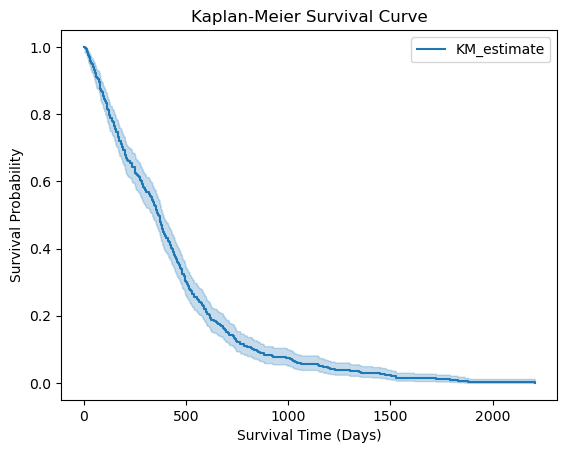

In [ ]:
path_4_clinical_info = 'Datasets/UPENN_GBM'

# Checks if survival days is available for patients
data_availability = pd.read_csv(os.path.join(pkg_path, path_4_clinical_info,'UPENN-GBM_data_availability.csv'))
data_availability = data_availability[data_availability['Overall Survival'] != 'not available']
patient_ids = data_availability['ID']

# Load clinical info
clinical_info = pd.read_csv(os.path.join(pkg_path,path_4_clinical_info, 'UPENN-GBM_clinical_info_v2.1.csv'))
clinical_info = clinical_info[clinical_info['ID'].isin(patient_ids)]
clinical_info = clinical_info.set_index('ID')

survival_days = clinical_info['Survival_from_surgery_days_UPDATED']

kmf_actual = KaplanMeierFitter()
kmf_actual.fit(durations=survival_days)

kmf_actual.plot()
plt.title("Kaplan-Meier Survival Curve")
plt.xlabel("Survival Time (Days)")
plt.ylabel("Survival Probability")
plt.show()

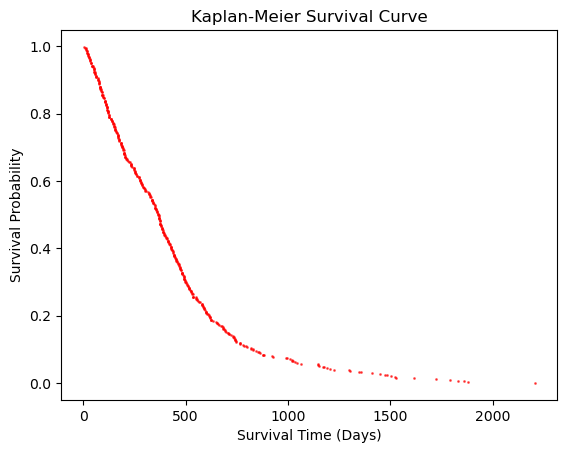

In [ ]:
survival_days = pd.to_numeric(survival_days)
event_survival_probs = [kmf_actual.predict(t) for t in survival_days]

plt.scatter(survival_days, event_survival_probs, color='red', marker='o',s=1, alpha=0.6)
plt.title("Kaplan-Meier Survival Curve: Actual survival")
plt.xlabel("Survival Time (Days)")
plt.ylabel("Survival Probability")
plt.show()

### How to tell if your model is doing anything
Graphical:
If the machine learning model predicts that a patient will survive for 100 days and it is a continuous prediction and the Kaplan-Meier curve to predicts survival probability at 100 days for the same patient to be 80% survival probability at 100 days, you could compare this to the actual survival time, graphically.

Statistical:
Or you can use a Log-Rank test to compare the survival curves between groups (e.g., patients with predicted survival less than 100 days vs. more than 100 days). This can give you a p-value to assess whether the model's prediction significantly differentiates between survival outcomes.


In [ ]:
# Graphical:
data= # Dataframe with ML model predictions
data['Event_Observed_Predicted'] = (data['Survival_Days'] <= data['Predicted_Survival']).astype(int)

kmf_predicted = KaplanMeierFitter()
kmf_predicted.fit(durations=data['Predicted_Survival'])

# Plot Kaplan-Meier curves
plt.figure(figsize=(10, 6))
kmf_actual.plot(label="Actual Survival")
kmf_predicted.plot(label="Predicted Survival", linestyle='--')

# Show plot
plt.title("Kaplan-Meier Survival Curves")
plt.xlabel("Time (Days)")
plt.ylabel("Survival Probability")
plt.legend()
plt.show()

In [ ]:
# Statistical:
actual_survival_data= # Clinical data
predicted_survival_data= # Dataframe with ML model predictions

results = logrank_test(actual_survival_data['Survival_Days'], predicted_survival_data['Predicted_Survival_Days'])
print("Log-Rank Test p-value:", results.p_value)

In [ ]:
# To do: 
# 1. Train a better models from the top modalities and extract the features from the best models
# 2. Compare models to Kaplin Meyer estimates-> Statistical significance/ p-values